In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torch import load

train_data = load('../data/train_data.pt',weights_only=False)
val_data = load('../data/val_data.pt',weights_only=False)
test_data = load('../data/test_data.pt',weights_only=False)

data = load('../data/data.pt',weights_only=False)

In [3]:
# (b) Build your Encoder which compute mu and logstd of a distribution
# and the train function associated
# class Encoder(nn.Module):
#     def __init__(...
from torch import nn
from torch_geometric.nn import GCNConv, VGAE

class Encoder(nn.Module):
    def __init__(self, dim_in,hidden_channels, dim_out):
        super(Encoder, self).__init__()
        self.conv1=GCNConv(dim_in, hidden_channels)
        self.conv_mu=GCNConv(hidden_channels, dim_out)
        self.conv_logstd = GCNConv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd

            
def train(model, train_data,val_data, optimizer, epochs):
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        # initialize the gradients
        optimizer.zero_grad()
        # forward pass
        z= model.encode(train_data.x, train_data.edge_index)
        #mu, logstd = model(data.x, data.edge_index)
        # compute the loss
        loss = model.recon_loss(
                z,
                train_data.pos_edge_label_index,
                train_data.neg_edge_label_index,
            ) + model.kl_loss() / train_data.num_nodes
        
        #loss=model.recon_loss(z, train_data.pos_edge_label_index,)
        #      +(1/train_data.num_nodes)*model.kl_loss()
        
        #loss = compute_loss(mu, logstd, data)
        print(f"Epoch {epoch}, Loss: {loss.item()}")
        # backpropagation and optimization step
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())
        # validation loss
        model.eval()
        #  attention, pour ne pas calculer les gradients sur les données de validation
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val,
                val_data.pos_edge_label_index,
                val_data.neg_edge_label_index,
            ) + model.kl_loss() / val_data.num_nodes
            print(f"Epoch {epoch}, Validation Loss: {val_loss.item()}")
            history["val"].append(val_loss.item())
    return history

In [4]:
# (c) Initialize your model using VGAE from torch geometric.nn, then train it
# here instanciate the model, then train and test it
from torch import device
model_a = VGAE(Encoder(data.num_features,32,16))

optimizer_a = th.optim.Adam(model_a.parameters(), lr=0.01)
loss_a =train(model_a, train_data, val_data, optimizer=optimizer_a, epochs=200)

model_b = VGAE(Encoder(data.num_features,128,16))
optimizer_b = th.optim.Adam(model_b.parameters(), lr=0.01)
loss_b = train(model_b, train_data, val_data, optimizer=optimizer_b, epochs=500)


model_c = VGAE(Encoder(data.num_features,6,6))
optimizer_c = th.optim.Adam(model_c.parameters(), lr=0.01)
loss_c = train(model_c, train_data, val_data, optimizer=optimizer_c, epochs=500)



Epoch 0, Loss: 98422456.0
Epoch 0, Validation Loss: 68715640.0
Epoch 1, Loss: 68715640.0
Epoch 1, Validation Loss: 47476092.0
Epoch 2, Loss: 47476088.0
Epoch 2, Validation Loss: 32819948.0
Epoch 3, Loss: 32819944.0
Epoch 3, Validation Loss: 23079126.0
Epoch 4, Loss: 23079120.0
Epoch 4, Validation Loss: 16824014.0
Epoch 5, Loss: 16824008.0
Epoch 5, Validation Loss: 12700346.0
Epoch 6, Loss: 12700339.0
Epoch 6, Validation Loss: 9950679.0
Epoch 7, Loss: 9950672.0
Epoch 7, Validation Loss: 7971305.5
Epoch 8, Loss: 7971299.0
Epoch 8, Validation Loss: 6549684.5
Epoch 9, Loss: 6549677.0
Epoch 9, Validation Loss: 5547658.0
Epoch 10, Loss: 5547650.0
Epoch 10, Validation Loss: 4925734.0
Epoch 11, Loss: 4925726.5
Epoch 11, Validation Loss: 4446089.5
Epoch 12, Loss: 4446082.0
Epoch 12, Validation Loss: 4096466.0
Epoch 13, Loss: 4096458.0
Epoch 13, Validation Loss: 3837013.75
Epoch 14, Loss: 3837005.75
Epoch 14, Validation Loss: 3672347.5
Epoch 15, Loss: 3672339.75
Epoch 15, Validation Loss: 359494

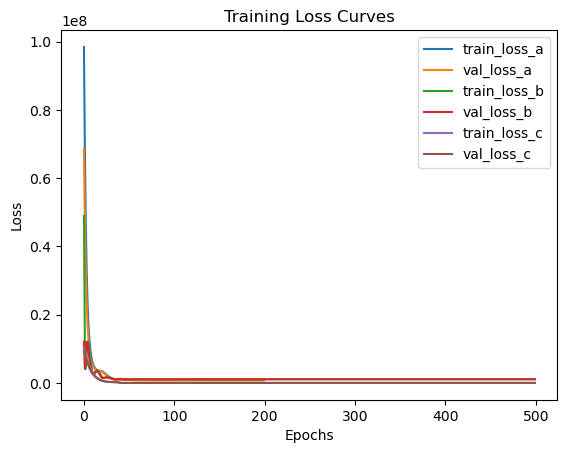

In [5]:
# afficher les courbes loss_a
import matplotlib.pyplot as plt
plt.plot(loss_a["train"], label="train_loss_a")
plt.plot(loss_a["val"], label="val_loss_a")
plt.plot(loss_b["train"], label="train_loss_b")
plt.plot(loss_b["val"], label="val_loss_b")
plt.plot(loss_c["train"], label="train_loss_c")
plt.plot(loss_c["val"], label="val_loss_c")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

In [ ]:
def afficher_matrice_confusion(lemodele,donnees_testees, titre):
    
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    
    with th.no_grad():
        
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)
        
        # Récupération de toutes les arêtes positives et négatives 
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf=lemodele.test(z, pos_edges, neg_edges)  
        predictions = (probabilites >= 0.5).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[1]} (vrai_positif/faux_positif) - AP {perf[2]} ( précision/rappel )")



afficher_matrice_confusion(model_a, train_data, "model_a train_data ")
afficher_matrice_confusion(model_a, test_data, "model_a test_data")

afficher_matrice_confusion(model_b, train_data, "model_b train_data ")
afficher_matrice_confusion(model_b, test_data, "model_b test_data")

afficher_matrice_confusion(model_c, train_data, "model_c train_data ")
afficher_matrice_confusion(model_c, test_data, "model_c test_data")
    


Matrice de confusion — model_a train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[4268 5216]
 [ 227 9257]]
Perf : AUC (vrai_positif/faux_positif) - AP ( précision/rappel )
— model_a train_data : (0.7160609497742741, 0.6389591251581812)

Matrice de confusion — model_a test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1205 1504]
 [  82 2627]]
Perf : AUC (vrai_positif/faux_positif) - AP ( précision/rappel )
— model_a test_data: (0.7103652550097217, 0.634569946801249)

Matrice de confusion — model_b train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[4420 5064]
 [ 429 9055]]
Perf : AUC (vrai_positif/faux_positif) - AP ( précision/rappel )
— model_b train_data : (0.7153283011579715, 0.6393294370503793)

Matrice de confusion — model_b test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1246 1463]
 [ 126 2583]]
Perf : AUC (vrai_positif/faux_positif) - AP ( pr

In [11]:
z  =model_a.encode(test_data.x, test_data.edge_index)
#
probabilites = model_a.decode(z, test_data.pos_edge_label_index, sigmoid=True)

pos_edges = test_data.pos_edge_label_index
neg_edges = test_data.neg_edge_label_index
perf=model_a.test(z, pos_edges, neg_edges)  
print(perf)

(0.7016869925263136, 0.6279549448461671)


In [7]:
test_data.pos_edge_label_index

tensor([[ 431, 1068,   16,  ..., 1929, 1044, 2589],
        [ 432, 1272,   93,  ..., 2085, 1314, 2598]])